=== LIGHTGBM FINGERPRINTING (DATA AGREGAT) - PELATIHAN & EVALUASI ===

Loading data for LightGBM from D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/5G_DL_full.xlsx...
  Konversi kolom fitur ke numerik (LightGBM bisa handle NaN)...
  Data LightGBM: Baris awal: 72480, Baris setelah cleaning targets: 72478
  Melatih model LightGBM pada data agregat...
  Applying StandardScaler to features for LightGBM...
  Training LightGBM model...
    LightGBM model training complete in 154.60 seconds.
  Model LightGBM (dan scaler jika ada) disimpan ke trained_models_lightgbm_aggregated\DL_filtered_2_with_metrics_nbr1_scaled_*.joblib

Mengevaluasi LightGBM pada data test agregat...

--- Evaluating LightGBM (Data Agregat) ---
  Distance Metrics: Mean_Err=7.27m, Median_Err=2.12m
  Prediction Time: Total=17.9580s, Avg/sample=1.2388ms
  R2 Score: Lat=0.997, Lon=0.998

--- Rangkuman Metrik Performa ---
Model: trained_models_lightgbm_aggregated\DL_filtered_2_with_metrics_nbr1_scaled
Waktu Training: 154

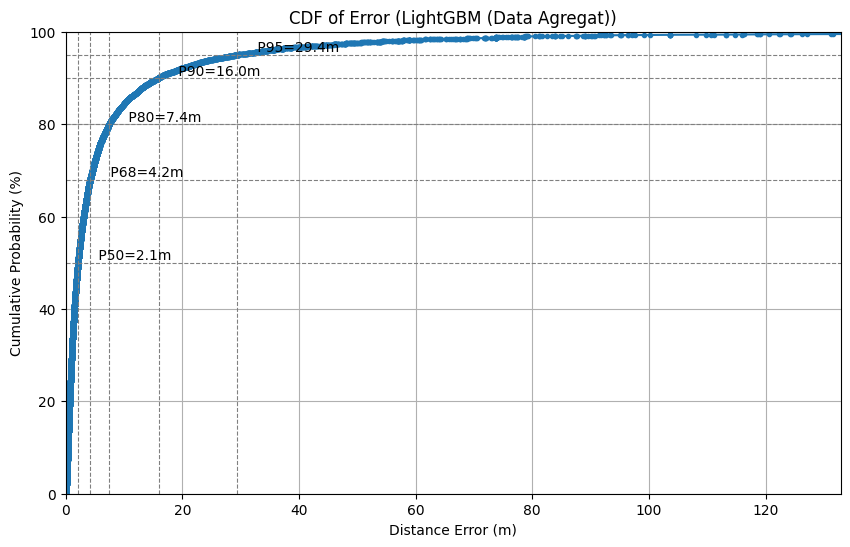


--- Feature Importance dari Model LightGBM ---
  Error menyimpan plot FI: [Errno 2] No such file or directory: 'trained_models_lightgbm_aggregated\\trained_models_lightgbm_aggregated\\DL_filtered_2_with_metrics_nbr1_scaled_feature_importance.png'


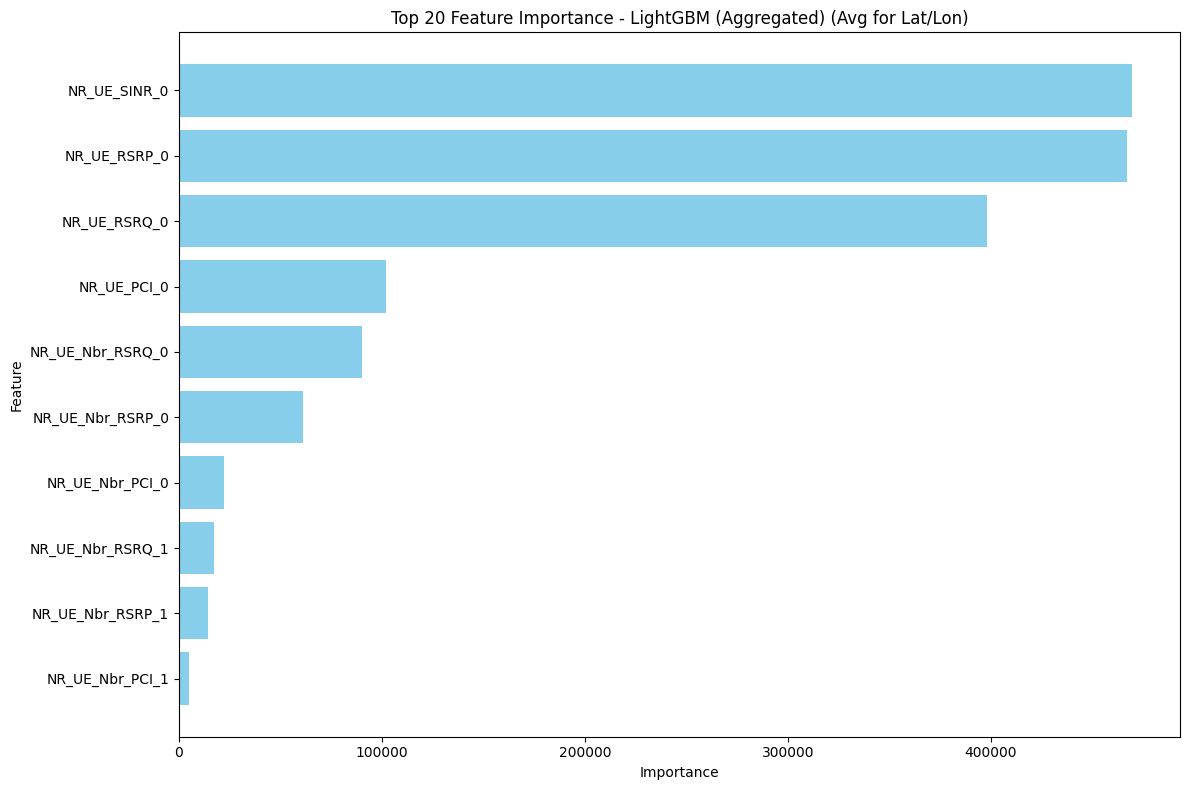

  Feature importance disimpan ke: trained_models_lightgbm_aggregated\trained_models_lightgbm_aggregated\DL_filtered_2_with_metrics_nbr1_scaled_feature_importance.csv
Memplot 14496 titik dari indeks 0 hingga 14495...


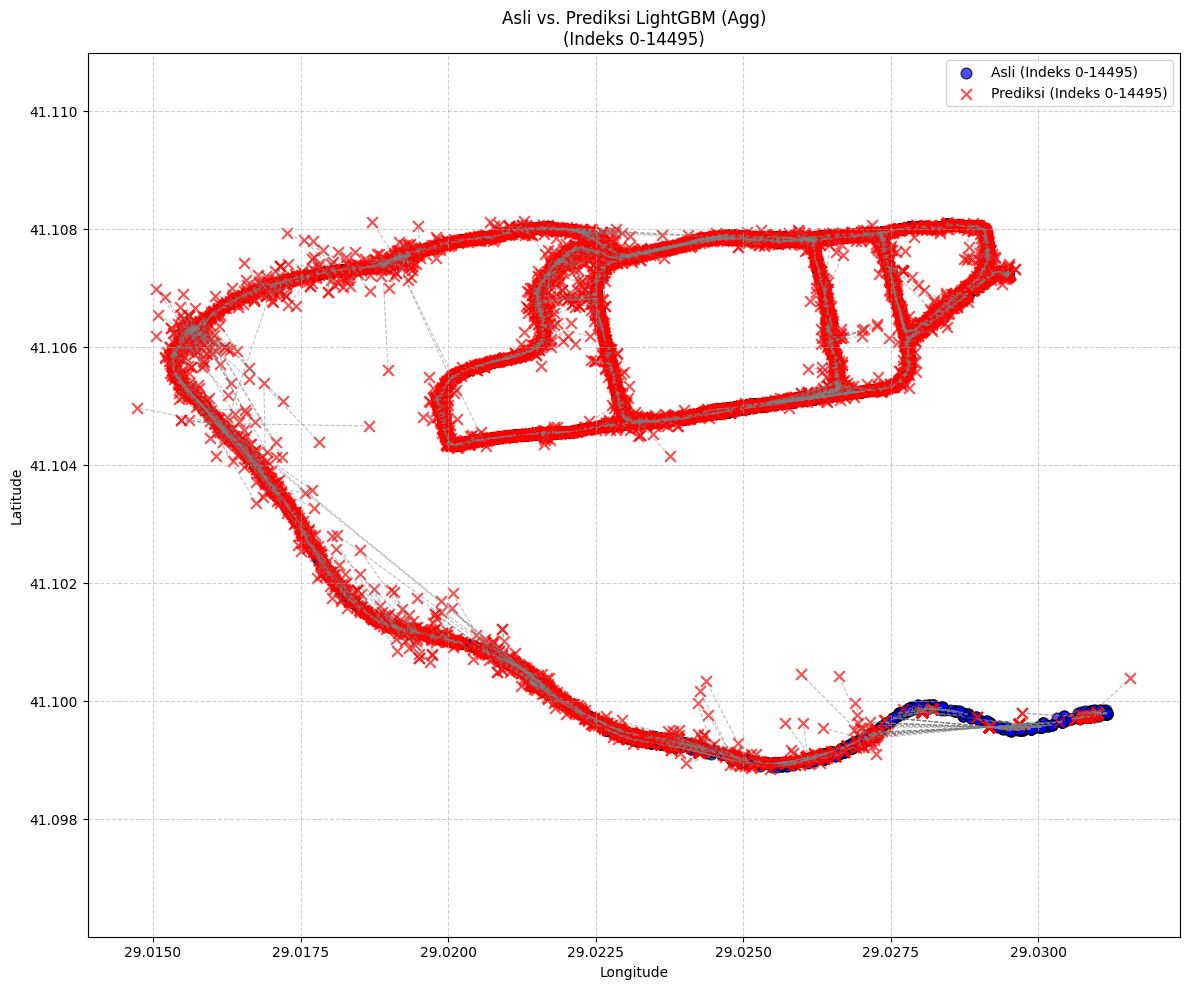



--- Skrip LightGBM Selesai ---


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
# --- BARU: Import metrik regresi tambahan ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, explained_variance_score
from math import radians, sin, cos, sqrt, atan2, asin
import matplotlib.pyplot as plt
import joblib
import os
import time # Sudah ada
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- Configuration ---
AGGREGATED_DATA_FILE_PATH = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/5G_DL_full.xlsx' # <--- GANTI
sheet = "Series_Formatted_Data" # Sesuaikan jika nama sheet berbeda

LGBM_PARAMS = {
    'objective': 'regression_l2', 'metric': 'rmse', 'n_estimators': 3000,
    'learning_rate': 0.04, 'num_leaves': 550, 'max_depth': -1,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 1,
    'min_child_samples': 20, 'verbose': -1, 'n_jobs': -1, 'random_state': 42
}
USE_SCALING_LGBM = True

MODEL_DIR_LGBM = "trained_models_lightgbm_aggregated"
MODEL_BASE_NAME_LGBM = os.path.join(MODEL_DIR_LGBM, "DL_filtered_2_with_metrics_nbr1_scaled") # Nama baru

# --- Helper Function: Haversine Distance (tetap sama) ---
def haversine(lat1, lon1, lat2, lon2):
    if any(pd.isna([lat1, lon1, lat2, lon2])): return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [float(lon1), float(lat1), float(lon2), float(lat2)])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * asin(sqrt(a)); r = 6371
    return c * r * 1000

# --- Load and Prepare Data Functions (tetap sama) ---
def load_and_prepare_data_for_lgbm(filepath, feature_cols_config, target_cols_config=['Latitude', 'Longitude']):
    print(f"Loading data for LightGBM from {filepath}...")
    try:
        if filepath.endswith('.xlsx'):
            df = pd.read_excel(filepath, sheet_name=sheet)
        elif filepath.endswith('.csv'):
            df = pd.read_csv(filepath, low_memory=False)
        else:
            print(f"Error: Format file tidak didukung: {filepath}"); return None, None, None, None
    except FileNotFoundError:
        print(f"Error: File '{filepath}' not found."); return None, None, None, None
    except Exception as e:
        print(f"Error saat membaca file Excel: {e}"); return None, None, None, None

    all_needed_cols = feature_cols_config + target_cols_config
    missing_cols_check = [col for col in all_needed_cols if col not in df.columns]
    if missing_cols_check:
        print(f"Error: Kolom yang dibutuhkan hilang: {missing_cols_check}. Kolom tersedia: {df.columns.tolist()}"); return None, None, None, None

    df_subset = df[all_needed_cols].copy()
    print("  Konversi kolom fitur ke numerik (LightGBM bisa handle NaN)...")
    for col in feature_cols_config:
        df_subset[col] = pd.to_numeric(df_subset[col], errors='coerce')

    df_clean = df_subset.dropna(subset=target_cols_config).reset_index(drop=True)
    print(f"  Data LightGBM: Baris awal: {len(df)}, Baris setelah cleaning targets: {len(df_clean)}")
    if df_clean.empty:
        print("  Error: Tidak ada data LightGBM yang bisa digunakan."); return None, None, None, None
    return df_clean[feature_cols_config], df_clean[target_cols_config[1]], df_clean[target_cols_config[0]], df_clean


# --- Train LightGBM Models Function (modifikasi untuk return training time) ---
def train_lgbm_model_with_scaler(X_train, y_train_latlon, lgbm_params, use_scaler=False):
    if X_train is None or X_train.empty:
        print("No training data for LightGBM."); return None, None, 0.0 # Tambah return training_time
    scaler = None
    X_train_processed = X_train.copy()
    if use_scaler:
        print("  Applying StandardScaler to features for LightGBM...")
        scaler = StandardScaler(); X_train_processed = scaler.fit_transform(X_train)
    
    print(f"  Training LightGBM model...")
    training_start_time = time.time() # Catat waktu mulai training
    base_lgbm = lgb.LGBMRegressor(**lgbm_params)
    multioutput_lgbm = MultiOutputRegressor(base_lgbm, n_jobs=-1)
    multioutput_lgbm.fit(X_train_processed, y_train_latlon)
    training_duration = time.time() - training_start_time # Hitung durasi
    print(f"    LightGBM model training complete in {training_duration:.2f} seconds.")
    return multioutput_lgbm, scaler, training_duration # Kembalikan durasi

# --- Save and Load Model/Scaler Functions (tetap sama) ---
def save_lgbm_model_and_scaler(model, scaler, base_filename):
    if not os.path.exists(MODEL_DIR_LGBM): os.makedirs(MODEL_DIR_LGBM)
    try:
        joblib.dump(model, f"{base_filename}_lgbm.joblib")
        if scaler: joblib.dump(scaler, f"{base_filename}_scaler.joblib")
        print(f"  Model LightGBM (dan scaler jika ada) disimpan ke {base_filename}_*.joblib")
    except Exception as e: print(f"  Error saving LightGBM model/scaler: {e}")

def load_lgbm_model_and_scaler(base_filename):
    # ... (fungsi ini tetap sama) ...
    model_path, scaler_path = f"{base_filename}_lgbm.joblib", f"{base_filename}_scaler.joblib"
    model, scaler = None, None
    if os.path.exists(model_path):
        try: model = joblib.load(model_path); print(f"  Model LightGBM dimuat dari {model_path}")
        except Exception as e: print(f"  Error memuat model LightGBM: {e}.")
    if USE_SCALING_LGBM and os.path.exists(scaler_path):
        try: scaler = joblib.load(scaler_path); print(f"  Scaler dimuat dari {scaler_path}")
        except Exception as e: print(f"  Error memuat scaler: {e}.")
    elif USE_SCALING_LGBM and not os.path.exists(scaler_path) and model is not None :
        print(f"  Peringatan: File scaler {scaler_path} tidak ditemukan, padahal USE_SCALING_LGBM=True.")
    if model is not None and (not USE_SCALING_LGBM or (USE_SCALING_LGBM and scaler is not None)):
        return model, scaler
    return None, None

# --- Fungsi Evaluasi (MODIFIKASI untuk metrik baru dan waktu prediksi) ---
def evaluate_lgbm_and_get_predictions_with_metrics(
    X_eval, y_actual_latlon, # y_actual_latlon adalah DataFrame dengan Lat, Lon
    lgbm_model, trained_scaler, 
    model_type_name):
    
    print(f"\n--- Evaluating {model_type_name} ---")
    if X_eval is None or X_eval.empty: print("No data for evaluation."); return {}, pd.DataFrame(), 0.0

    X_eval_processed = X_eval.copy()
    if trained_scaler: X_eval_processed = trained_scaler.transform(X_eval)
    
    # Ukur waktu prediksi
    prediction_start_time = time.time()
    y_pred_latlon_array = lgbm_model.predict(X_eval_processed)
    prediction_duration = time.time() - prediction_start_time
    avg_prediction_time_per_sample = (prediction_duration / len(X_eval)) * 1000 if len(X_eval) > 0 else 0 # dalam ms

    results_df = pd.DataFrame({
        'true_lat': y_actual_latlon[TARGET_COLS_LGBM[0]].values,
        'true_lon': y_actual_latlon[TARGET_COLS_LGBM[1]].values,
        'pred_lat': y_pred_latlon_array[:, 0],
        'pred_lon': y_pred_latlon_array[:, 1]
    })
    if y_actual_latlon.index.name is not None or not y_actual_latlon.index.equals(pd.RangeIndex(start=0, stop=len(y_actual_latlon), step=1)):
        results_df.index = y_actual_latlon.index

    distances = []
    for i in range(len(results_df)):
        row = results_df.iloc[i]; dist = haversine(row['true_lat'], row['true_lon'], row['pred_lat'], row['pred_lon'])
        if not pd.isna(dist): distances.append(dist)
        results_df.loc[results_df.index[i], 'error_m'] = dist
    
    performance_metrics = {}
    if not distances:
        print("No valid distances calculated for distance-based metrics.")
    else:
        distances_arr = np.array(distances)
        performance_metrics['mean_error_m'] = np.nanmean(distances_arr)
        performance_metrics['median_error_m'] = np.nanmedian(distances_arr)
        performance_metrics['rmse_error_m'] = np.sqrt(np.nanmean(np.square(distances_arr)))
        performance_metrics['std_dev_error_m'] = np.nanstd(distances_arr)
        # Persentil bisa ditambahkan di sini atau dihitung dari distances_arr nanti
        performance_metrics['p50_error_m'] = np.percentile(distances_arr, 50)
        performance_metrics['p95_error_m'] = np.percentile(distances_arr, 95)
        print(f"  Distance Metrics: Mean_Err={performance_metrics['mean_error_m']:.2f}m, Median_Err={performance_metrics['median_error_m']:.2f}m")

    # Metrik regresi Scikit-learn per target (Lat, Lon)
    true_lat_vals = results_df['true_lat'].values
    pred_lat_vals = results_df['pred_lat'].values
    true_lon_vals = results_df['true_lon'].values
    pred_lon_vals = results_df['pred_lon'].values

    performance_metrics['mae_lat_deg'] = mean_absolute_error(true_lat_vals, pred_lat_vals)
    performance_metrics['mae_lon_deg'] = mean_absolute_error(true_lon_vals, pred_lon_vals)
    performance_metrics['medae_lat_deg'] = median_absolute_error(true_lat_vals, pred_lat_vals)
    performance_metrics['medae_lon_deg'] = median_absolute_error(true_lon_vals, pred_lon_vals)
    performance_metrics['rmse_lat_deg'] = np.sqrt(mean_squared_error(true_lat_vals, pred_lat_vals))
    performance_metrics['rmse_lon_deg'] = np.sqrt(mean_squared_error(true_lon_vals, pred_lon_vals))
    performance_metrics['r2_lat'] = r2_score(true_lat_vals, pred_lat_vals)
    performance_metrics['r2_lon'] = r2_score(true_lon_vals, pred_lon_vals)
    performance_metrics['explained_variance_lat'] = explained_variance_score(true_lat_vals, pred_lat_vals)
    performance_metrics['explained_variance_lon'] = explained_variance_score(true_lon_vals, pred_lon_vals)
    
    performance_metrics['prediction_time_total_s'] = prediction_duration
    performance_metrics['prediction_time_avg_ms_per_sample'] = avg_prediction_time_per_sample

    print(f"  Prediction Time: Total={prediction_duration:.4f}s, Avg/sample={avg_prediction_time_per_sample:.4f}ms")
    print(f"  R2 Score: Lat={performance_metrics['r2_lat']:.3f}, Lon={performance_metrics['r2_lon']:.3f}")
    
    return performance_metrics, results_df, distances_arr # Kembalikan juga distances_arr untuk CDF


# --- Fungsi Plot (plot_cdf_from_distances, plot_predictions_on_map_indexed, plot_feature_importance tetap sama) ---
def plot_cdf_from_distances(distances_array, model_title_suffix, plot_save_path=None):
    # ... (fungsi ini tetap sama) ...
    if distances_array is None or len(distances_array) == 0: print(f"No distances for CDF {model_title_suffix}."); return
    sorted_distances = np.sort(distances_array); cum_prob = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
    plt.figure(figsize=(10, 6)); plt.plot(sorted_distances, cum_prob * 100, marker='.', linestyle='-')
    plt.title(f'CDF of Error ({model_title_suffix})'); plt.xlabel('Distance Error (m)'); plt.ylabel('Cumulative Probability (%)')
    plt.grid(True); xlim_max = max(20, np.percentile(sorted_distances, 99.5) if len(sorted_distances) > 0 else 20)
    plt.xlim(left=0, right=xlim_max); plt.ylim(0, 100)
    percentiles = [50, 68, 80, 90, 95];
    for p in percentiles:
        if len(sorted_distances) > 0:
            val_p = np.percentile(sorted_distances, p); plt.axhline(p, color='gray', ls='--', lw=0.8); plt.axvline(val_p, color='gray', ls='--', lw=0.8)
            plt.text(min(val_p + xlim_max * 0.02, xlim_max * 0.95), p, f' P{p}={val_p:.1f}m', va='bottom', ha='left')
    if plot_save_path:
        try: plt.savefig(plot_save_path); print(f"  CDF plot saved to: {plot_save_path}")
        except Exception as e: print(f"  Error saving CDF plot: {e}")
    plt.show(); plt.close()

def plot_predictions_on_map_indexed(results_with_predictions_df, index_start, index_end, title_suffix=""):
    # ... (fungsi ini tetap sama) ...
    if results_with_predictions_df.empty: print("DataFrame hasil prediksi kosong."); return
    if not all(c in results_with_predictions_df.columns for c in ['true_lat','true_lon','pred_lat','pred_lon']): print("Kolom plot hilang."); return
    try: subset_to_plot = results_with_predictions_df.iloc[index_start:index_end]
    except IndexError: print(f"Indeks {index_start}-{index_end} di luar batas."); subset_to_plot = results_with_predictions_df
    if subset_to_plot.empty: print(f"Tidak ada data di indeks {index_start}-{index_end}."); return
    print(f"Memplot {len(subset_to_plot)} titik dari indeks {index_start} hingga {index_end-1}...")
    plt.figure(figsize=(12, 10))
    plt.scatter(subset_to_plot['true_lon'],subset_to_plot['true_lat'],c='blue',label=f'Asli (Indeks {index_start}-{index_end-1})',alpha=0.7,s=60,edgecolor='k')
    plt.scatter(subset_to_plot['pred_lon'],subset_to_plot['pred_lat'],c='red',label=f'Prediksi (Indeks {index_start}-{index_end-1})',alpha=0.7,s=60,marker='x')
    for i in range(len(subset_to_plot)):
        plt.plot([subset_to_plot.iloc[i]['true_lon'],subset_to_plot.iloc[i]['pred_lon']],
                 [subset_to_plot.iloc[i]['true_lat'],subset_to_plot.iloc[i]['pred_lat']], 'grey',ls='--',lw=0.8,alpha=0.5)
    plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.title(f"Asli vs. Prediksi {title_suffix}\n(Indeks {index_start}-{index_end-1})",fontsize=12)
    plt.legend(); plt.grid(True,ls='--',alpha=0.6); plt.axis('equal'); plt.tight_layout(); plt.show(); plt.close()

def plot_feature_importance(model, feature_names, model_name="LightGBM", top_n=20):
    # ... (fungsi ini tetap sama) ...
    if not hasattr(model, 'estimators_'):
        if hasattr(model, 'feature_importances_'): importances_single = model.feature_importances_
        else: print(f"Model {model_name} tidak memiliki 'estimators_' atau 'feature_importances_'."); return None
        feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances_single})
        title = f"Top {top_n} Feature Importance - {model_name} (Single Estimator)"
    else:
        importances_lat = model.estimators_[0].feature_importances_
        importances_lon = model.estimators_[1].feature_importances_
        avg_importances = (importances_lat + importances_lon) / 2
        feature_importance_df = pd.DataFrame({'feature':feature_names,'importance_lat':importances_lat,'importance_lon':importances_lon,'importance_avg':avg_importances})
        feature_importance_df = feature_importance_df.sort_values(by='importance_avg', ascending=False)
        title = f"Top {top_n} Feature Importance - {model_name} (Avg for Lat/Lon)"
    feature_importance_df = feature_importance_df.head(top_n)
    plt.figure(figsize=(12, int(max(8,top_n*0.4)))); y_pos = np.arange(len(feature_importance_df))
    plot_values = feature_importance_df['importance_avg'] if 'importance_avg' in feature_importance_df else feature_importance_df['importance']
    plt.barh(y_pos, plot_values, align='center', color='skyblue'); plt.yticks(y_pos, feature_importance_df['feature'])
    plt.xlabel("Importance"); plt.ylabel("Feature"); plt.title(title); plt.gca().invert_yaxis(); plt.tight_layout()
    fi_plot_path = os.path.join(MODEL_DIR_LGBM, f"{MODEL_BASE_NAME_LGBM}_feature_importance.png") # Simpan FI
    try: plt.savefig(fi_plot_path); print(f"  Plot Feature Importance disimpan ke: {fi_plot_path}")
    except Exception as e: print(f"  Error menyimpan plot FI: {e}")
    plt.show(); plt.close()
    return feature_importance_df

# --- Main Execution ---
if __name__ == "__main__":
    if not os.path.exists(MODEL_DIR_LGBM): os.makedirs(MODEL_DIR_LGBM)
    print("=== LIGHTGBM FINGERPRINTING (DATA AGREGAT) - PELATIHAN & EVALUASI ===\n")
    
    FEATURE_COLS_LGBM = [
        # 'NR_UE_Pathloss_DL_0',
        'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
        'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRP_0','NR_UE_Nbr_PCI_0',
        'NR_UE_Nbr_RSRQ_1', 'NR_UE_Nbr_RSRP_1','NR_UE_Nbr_PCI_1',
        # 'NR_UE_Modulation_Avg_DL_0', 'NR_UE_RI_DL_0', 'NR_UE_CCE_AggregationLev_0',
        # 'NR_UE_Throughput_PDCP_DL', 'App_Throughput_DL', # Contoh fitur tambahan

# 'NR_Scan_PCI_SortedBy_RSRP_0',
# 'NR_Scan_PCI_SortedBy_RSRP_1',
# 'NR_Scan_PCI_SortedBy_RSRP_2',
# 'NR_Scan_PCI_SortedBy_RSRP_3',
# # 'NR_Scan_PCI_SortedBy_RSRP_4',
# # 'NR_Scan_PCI_SortedBy_RSRP_5',
# # 'NR_Scan_PCI_SortedBy_RSRP_6',


# 'NR_Scan_SSB_RSRP_SortedBy_RSRP_0',
# 'NR_Scan_SSB_RSRP_SortedBy_RSRP_1',
# 'NR_Scan_SSB_RSRP_SortedBy_RSRP_2',
# 'NR_Scan_SSB_RSRP_SortedBy_RSRP_3',
# # 'NR_Scan_SSB_RSRP_SortedBy_RSRP_4',
# # 'NR_Scan_SSB_RSRP_SortedBy_RSRP_5',
# # 'NR_Scan_SSB_RSRP_SortedBy_RSRP_6',

# 'NR_Scan_SSB_RSRQ_SortedBy_RSRP_0',
# 'NR_Scan_SSB_RSRQ_SortedBy_RSRP_1',
# 'NR_Scan_SSB_RSRQ_SortedBy_RSRP_2',
# 'NR_Scan_SSB_RSRQ_SortedBy_RSRP_3',
# # 'NR_Scan_SSB_RSRQ_SortedBy_RSRP_4',
# # 'NR_Scan_SSB_RSRQ_SortedBy_RSRP_5',
# # 'NR_Scan_SSB_RSRQ_SortedBy_RSRP_6',

# 'NR_Scan_SSB_SINR_SortedBy_RSRP_0',
# 'NR_Scan_SSB_SINR_SortedBy_RSRP_1',
# 'NR_Scan_SSB_SINR_SortedBy_RSRP_2',
# 'NR_Scan_SSB_SINR_SortedBy_RSRP_3',
# # 'NR_Scan_SSB_SINR_SortedBy_RSRP_4',
# # 'NR_Scan_SSB_SINR_SortedBy_RSRP_5',
# # 'NR_Scan_SSB_SINR_SortedBy_RSRP_6',


    ]
    TARGET_COLS_LGBM = ['Latitude', 'Longitude']

    X_agg_full, y_lon_agg_full, y_lat_agg_full, df_clean_agg_full = \
        load_and_prepare_data_for_lgbm(AGGREGATED_DATA_FILE_PATH, FEATURE_COLS_LGBM, TARGET_COLS_LGBM)

    if X_agg_full is None or X_agg_full.empty:
        print("FATAL: Gagal memuat/mempersiapkan data. Skrip dihentikan."); exit()

    y_agg_full_latlon = pd.DataFrame({
        TARGET_COLS_LGBM[0]: y_lat_agg_full, TARGET_COLS_LGBM[1]: y_lon_agg_full
    }, index=X_agg_full.index)

    X_agg_train, X_agg_test, y_agg_train_latlon, y_agg_test_latlon = train_test_split(
        X_agg_full, y_agg_full_latlon, test_size=0.2, random_state=42, shuffle=True
    )
    
    lgbm_model_trained, scaler_lgbm_trained, training_time_sec = (None, None, 0.0) # Inisialisasi training_time_sec
    # Coba muat model dulu
    # lgbm_model_trained, scaler_lgbm_trained = load_lgbm_model_and_scaler(MODEL_BASE_NAME_LGBM) # Fungsi load dari skrip sebelumnya
    # Untuk contoh ini, kita akan selalu training, tapi Anda bisa uncomment load jika mau
    
    # if lgbm_model_trained is None: # Jika model tidak ada atau gagal dimuat
    print("  Melatih model LightGBM pada data agregat...")
    lgbm_model_trained, scaler_lgbm_trained, training_time_sec = train_lgbm_model_with_scaler( # Tangkap training_time_sec
        X_agg_train, y_agg_train_latlon, LGBM_PARAMS, use_scaler=USE_SCALING_LGBM
    )
    if lgbm_model_trained:
        save_lgbm_model_and_scaler(lgbm_model_trained, scaler_lgbm_trained, MODEL_BASE_NAME_LGBM)
    else:
        print("FATAL: Pelatihan model gagal. Skrip dihentikan."); exit()
    # else:
    #     print("Model LightGBM berhasil dimuat dari file.")
    
    # Evaluasi
    if lgbm_model_trained:
        print("\nMengevaluasi LightGBM pada data test agregat...")
        # --- MODIFIKASI PEMANGGILAN EVALUASI ---
        performance_results, results_df_lgbm_agg, distances_lgbm_agg = evaluate_lgbm_and_get_predictions_with_metrics(
            X_agg_test, y_agg_test_latlon, lgbm_model_trained, scaler_lgbm_trained,
            "LightGBM (Data Agregat)"
        )
        # --------------------------------------
        
        # Cetak semua metrik performa
        print("\n--- Rangkuman Metrik Performa ---")
        print(f"Model: {MODEL_BASE_NAME_LGBM}")
        print(f"Waktu Training: {training_time_sec:.2f} detik")
        if performance_results: # Cek jika dictionary tidak kosong
            for metric_name, metric_value in performance_results.items():
                if isinstance(metric_value, float):
                    unit = ""
                    if "_m" in metric_name: unit = " m"
                    elif "_deg" in metric_name: unit = " deg"
                    elif "_s" in metric_name and "ms" not in metric_name : unit = " s"
                    elif "_ms" in metric_name: unit = " ms"
                    print(f"  {metric_name.replace('_', ' ').title()}: {metric_value:.3f}{unit}")
                else:
                    print(f"  {metric_name.replace('_', ' ').title()}: {metric_value}")
        print("---------------------------------")

        cdf_plot_path_lgbm = os.path.join(MODEL_DIR_LGBM, f"{MODEL_BASE_NAME_LGBM}_test_cdf.png")
        plot_cdf_from_distances(distances_lgbm_agg, "LightGBM (Data Agregat)", cdf_plot_path_lgbm)
        
        print("\n--- Feature Importance dari Model LightGBM ---")
        feature_names_for_importance = X_agg_train.columns.tolist()
        fi_df = plot_feature_importance(lgbm_model_trained, feature_names_for_importance, model_name="LightGBM (Aggregated)")
        if fi_df is not None:
            fi_csv_path = os.path.join(MODEL_DIR_LGBM, f"{MODEL_BASE_NAME_LGBM}_feature_importance.csv")
            # fi_df.to_csv(fi_csv_path, index=False)
            print(f"  Feature importance disimpan ke: {fi_csv_path}")


        if not results_df_lgbm_agg.empty:
            try:
                idx_start = 0; idx_end = len(results_df_lgbm_agg)
                plot_predictions_on_map_indexed(results_df_lgbm_agg, idx_start, idx_end, title_suffix="LightGBM (Agg)")
            except Exception as e: print(f"Error plot peta LGBM: {e}")
        else: print("Tidak ada hasil prediksi LGBM untuk diplot.")
    else:
        print("Model LightGBM (agregat) tidak tersedia untuk evaluasi/plotting.")

    print("\n\n--- Skrip LightGBM Selesai ---")

=== LIGHTGBM FINGERPRINTING (DATA AGREGAT) ===
Loading data for LightGBM from D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/Scanner_fill.xlsx...
  Konversi kolom fitur ke numerik dan imputasi NaN (LightGBM bisa handle NaN)...
  Data LightGBM: Baris awal: 22392, Baris setelah cleaning targets: 22392

Membagi data agregat menjadi set train dan test (80/20) untuk LightGBM...
  Melatih model LightGBM pada data agregat...
  Training LightGBM model...
    LightGBM model training complete.
  Model LightGBM (dan scaler jika ada) disimpan ke trained_models_lightgbm_aggregated\Scanner_TES_*.joblib

Mengevaluasi LightGBM pada data test agregat...

--- Evaluating LightGBM (Data Agregat) ---
  Mean error: 4.40m, Median: 1.80m
  Error saving CDF plot: [Errno 2] No such file or directory: 'trained_models_lightgbm_aggregated\\trained_models_lightgbm_aggregated\\Scanner_TES_test_cdf.png'


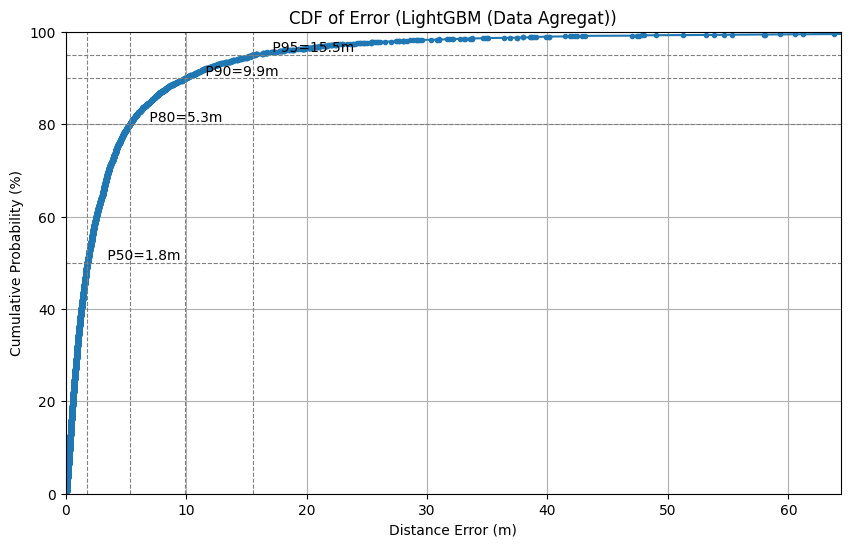

Indeks tidak valid. Default 0-10.
Memplot 4479 titik dari indeks 0 hingga 4478...


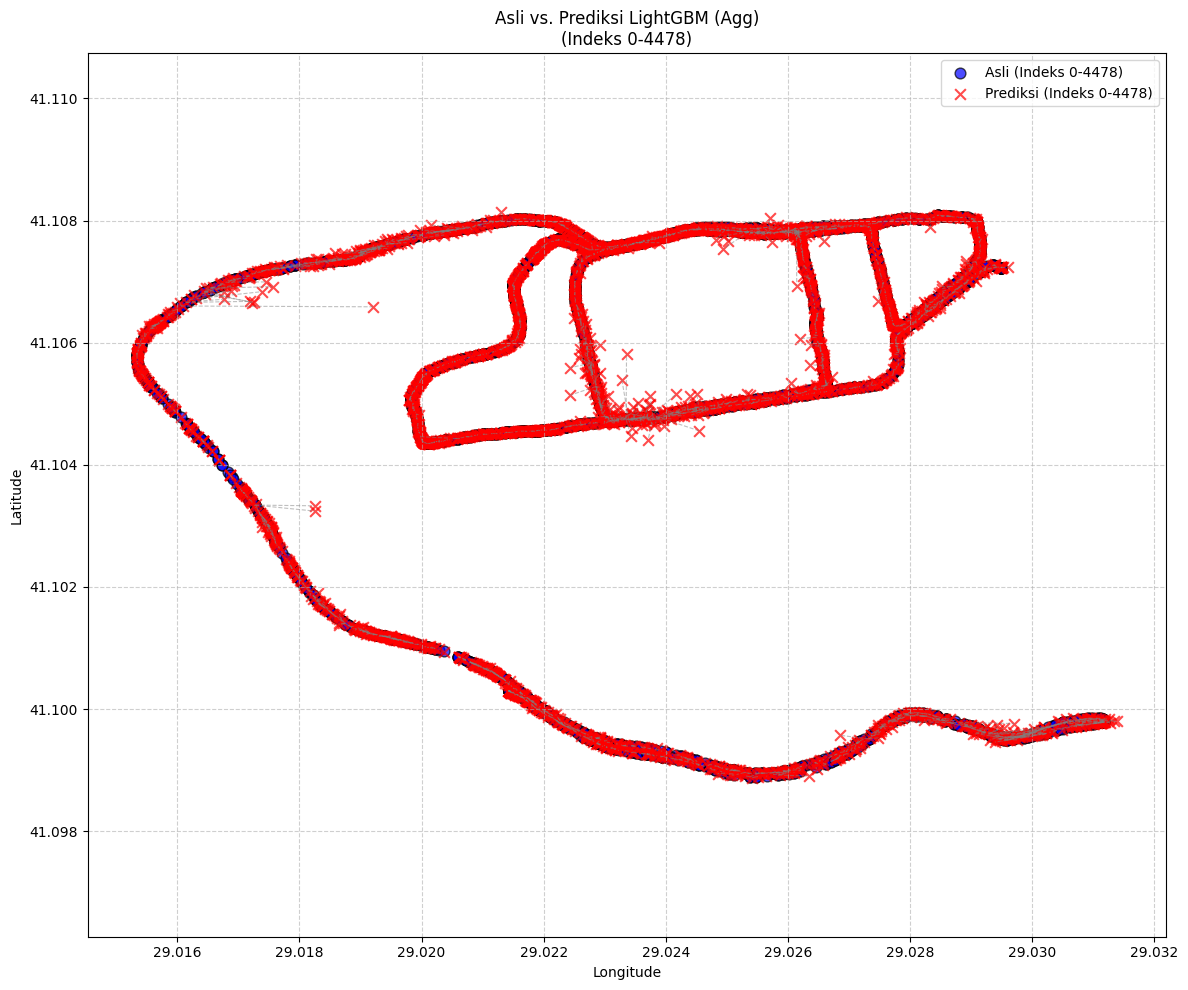



--- Skrip LightGBM Selesai ---


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Opsional untuk LightGBM, tapi bisa dicoba
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor # Untuk menangani Lat/Lon
from math import radians, sin, cos, sqrt, atan2, asin
import matplotlib.pyplot as plt
import joblib # For saving/loading models
import os     # For checking if files exist
import warnings

# Menonaktifkan beberapa jenis peringatan
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None


# --- Configuration ---
# Path ke file data Anda yang SUDAH DIAGREGASI PER JENDELA WAKTU
AGGREGATED_DATA_FILE_PATH = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/Scanner_fill.xlsx' # <--- tGANTI INI
sheet =  "Series_Formatted_Data" #Series_Formatted_Data

# Konfigurasi LightGBM
LGBM_PARAMS = { # Anda bisa melakukan tuning hyperparameter ini nanti
    'objective': 'regression_l2', # atau 'regression_l1' (MAE), 'huber', 'quantile'
    'metric': 'rmse', # Metrik evaluasi internal LightGBM
    'n_estimators': 3000,      # Jumlah pohon (boosting rounds)
    'learning_rate': 0.04, #kurangi untuk masalah lebih kompleks 0.05
    'num_leaves': 550,         # Jumlah daun maksimum di satu pohon
    'max_depth': -1,          # Tidak ada batasan kedalaman pohon (-1)
    'feature_fraction': 0.8,  # Persentase fitur yang dipilih per pohon (untuk bagging fitur)
    'bagging_fraction': 0.8,  # Persentase data yang dipilih per iterasi (untuk bagging data)
    'bagging_freq': 1,        # Frekuensi bagging (setiap berapa iterasi)
    'min_child_samples': 20,  # Jumlah sampel minimum di satu leaf
    'verbose': -1,            # Kontrol output log (-1 = silent)
    'n_jobs': -1,             # Gunakan semua core CPU
    'random_state': 42        # Untuk reproduktisibilitas (LightGBM pakai 'seed' atau 'random_state')
}
# Apakah akan menggunakan StandardScaler? LightGBM biasanya tidak terlalu butuh, tapi bisa dicoba.
USE_SCALING_LGBM = False

# Model save paths
MODEL_DIR_LGBM = "trained_models_lightgbm_aggregated" # Direktori baru untuk model LightGBM
MODEL_BASE_NAME_LGBM = os.path.join(MODEL_DIR_LGBM, "Scanner_TES") # Nama dasar model

# --- Helper Function: Haversine Distance (tetap sama) ---
def haversine(lat1, lon1, lat2, lon2):
    if any(pd.isna([lat1, lon1, lat2, lon2])): return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [float(lon1), float(lat1), float(lon2), float(lat2)])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * asin(sqrt(a)); r = 6371
    return c * r * 1000

# --- Load and Prepare Data Functions ---
def load_and_prepare_data_for_lgbm(filepath, feature_cols_config, target_cols_config=['Latitude', 'Longitude']):
    """Memuat data (agregat), memilih fitur, konversi numerik, dan imputasi sederhana."""
    print(f"Loading data for LightGBM from {filepath}...")
    try:
        if filepath.endswith('.xlsx'):
            df = pd.read_excel(filepath, sheet_name=sheet)
        elif filepath.endswith('.csv'):
            df = pd.read_csv(filepath, low_memory=False)
        else:
            print(f"Error: Format file tidak didukung: {filepath}"); return None, None, None, None
    except FileNotFoundError:
        print(f"Error: File '{filepath}' not found."); return None, None, None, None
    
    all_needed_cols = feature_cols_config + target_cols_config
    missing_cols_check = [col for col in all_needed_cols if col not in df.columns]
    if missing_cols_check:
        print(f"Error: Kolom yang dibutuhkan hilang: {missing_cols_check}. Kolom tersedia: {df.columns.tolist()}"); return None, None, None, None

    df_subset = df[all_needed_cols].copy()
    print("  Konversi kolom fitur ke numerik dan imputasi NaN (LightGBM bisa handle NaN)...")
    for col in feature_cols_config:
        # LightGBM bisa menangani NaN secara internal, jadi kita bisa biarkan NaN
        # atau imputasi jika kita mau. Untuk saat ini, kita coba biarkan NaN setelah konversi.
        df_subset[col] = pd.to_numeric(df_subset[col], errors='coerce')
        # Jika Anda ingin imputasi sebelum LightGBM:
        # if df_subset[col].isnull().any():
        #     median_val = df_subset[col].median()
        #     fill_val = median_val if pd.notna(median_val) else 0 
        #     df_subset[col].fillna(fill_val, inplace=True)
            # print(f"    Imputed NaNs in '{col}' with {fill_val}.")

    # Buang baris jika target (Lat/Lon) adalah NaN
    df_clean = df_subset.dropna(subset=target_cols_config).reset_index(drop=True)
    
    print(f"  Data LightGBM: Baris awal: {len(df)}, Baris setelah cleaning targets: {len(df_clean)}")
    if df_clean.empty:
        print("  Error: Tidak ada data LightGBM yang bisa digunakan."); return None, None, None, None
    
    return df_clean[feature_cols_config], df_clean[target_cols_config[1]], df_clean[target_cols_config[0]], df_clean
    # Mengembalikan Lon dulu, lalu Lat


# --- Train LightGBM Models Function ---
def train_lgbm_model_with_scaler(X_train, y_train_latlon, lgbm_params, use_scaler=False):
    """Melatih model LightGBM (dengan MultiOutputRegressor) dan scaler (opsional)."""
    if X_train is None or X_train.empty:
        print("No training data for LightGBM."); return None, None
    
    scaler = None
    X_train_processed = X_train.copy() # Bekerja pada salinan

    if use_scaler:
        print("  Applying StandardScaler to features for LightGBM...")
        scaler = StandardScaler()
        X_train_processed = scaler.fit_transform(X_train) # Menjadi array NumPy
    
    print(f"  Training LightGBM model...")
    # Inisialisasi model dasar LightGBM
    base_lgbm = lgb.LGBMRegressor(**lgbm_params)
    
    # Bungkus dengan MultiOutputRegressor untuk prediksi Lat dan Lon
    multioutput_lgbm = MultiOutputRegressor(base_lgbm, n_jobs=-1) # n_jobs untuk MultiOutputRegressor
    
    multioutput_lgbm.fit(X_train_processed, y_train_latlon) # y_train_latlon harus DataFrame dengan kolom Lat, Lon
    print(f"    LightGBM model training complete.")
    return multioutput_lgbm, scaler


# --- Save and Load Model/Scaler Functions (bisa dipakai ulang) ---
def save_lgbm_model_and_scaler(model, scaler, base_filename):
    if not os.path.exists(MODEL_DIR_LGBM): os.makedirs(MODEL_DIR_LGBM)
    try:
        joblib.dump(model, f"{base_filename}_lgbm.joblib")
        if scaler: joblib.dump(scaler, f"{base_filename}_scaler.joblib")
        print(f"  Model LightGBM (dan scaler jika ada) disimpan ke {base_filename}_*.joblib")
    except Exception as e: print(f"  Error saving LightGBM model/scaler: {e}")

def load_lgbm_model_and_scaler(base_filename):
    model_path = f"{base_filename}_lgbm.joblib"
    scaler_path = f"{base_filename}_scaler.joblib" # Path scaler tetap sama
    
    model, scaler = None, None
    if os.path.exists(model_path):
        try: model = joblib.load(model_path); print(f"  Model LightGBM dimuat dari {model_path}")
        except Exception as e: print(f"  Error memuat model LightGBM: {e}. Akan dilatih ulang.")
    
    if USE_SCALING_LGBM and os.path.exists(scaler_path): # Hanya muat scaler jika USE_SCALING_LGBM True
        try: scaler = joblib.load(scaler_path); print(f"  Scaler dimuat dari {scaler_path}")
        except Exception as e: print(f"  Error memuat scaler: {e}. Scaler akan di-fit ulang jika scaling aktif.")
    elif USE_SCALING_LGBM and not os.path.exists(scaler_path):
        print(f"  File scaler {scaler_path} tidak ditemukan, akan di-fit ulang jika scaling aktif.")

    if model is not None and (not USE_SCALING_LGBM or (USE_SCALING_LGBM and scaler is not None)):
        return model, scaler
    return None, None # Jika model tidak ada atau scaler dibutuhkan tapi tidak ada


# --- Fungsi Evaluasi dan Plot (bisa dipakai ulang dari GPR, hanya perlu model dan scaler) ---
def evaluate_lgbm_and_get_predictions(X_eval, y_actual_latlon, # y_actual_latlon adalah DataFrame dengan Lat, Lon
                                    lgbm_model, trained_scaler, # trained_scaler bisa None jika tidak digunakan
                                    model_type_name):
    print(f"\n--- Evaluating {model_type_name} ---")
    if X_eval is None or X_eval.empty: print("No data for evaluation."); return np.array([]), pd.DataFrame()

    X_eval_processed = X_eval.copy()
    if trained_scaler: # Hanya transform jika scaler ada (yaitu, jika USE_SCALING_LGBM True)
        X_eval_processed = trained_scaler.transform(X_eval)
    
    y_pred_latlon_array = lgbm_model.predict(X_eval_processed) # Hasilnya array [pred_lat, pred_lon]

    results_df = pd.DataFrame({
        'true_lat': y_actual_latlon[TARGET_COLS_LGBM[0]].values, # Asumsi TARGET_COLS_LGBM[0] adalah Latitude
        'true_lon': y_actual_latlon[TARGET_COLS_LGBM[1]].values, # Asumsi TARGET_COLS_LGBM[1] adalah Longitude
        'pred_lat': y_pred_latlon_array[:, 0], # Kolom pertama dari prediksi adalah Latitude
        'pred_lon': y_pred_latlon_array[:, 1]  # Kolom kedua adalah Longitude
    })
    if y_actual_latlon.index.name is not None or not y_actual_latlon.index.equals(pd.RangeIndex(start=0, stop=len(y_actual_latlon), step=1)):
        results_df.index = y_actual_latlon.index

    distances = []
    for i in range(len(results_df)):
        row = results_df.iloc[i]; dist = haversine(row['true_lat'], row['true_lon'], row['pred_lat'], row['pred_lon'])
        if not pd.isna(dist): distances.append(dist)
        results_df.loc[results_df.index[i], 'error_m'] = dist
    if not distances: print("No valid distances."); return np.array([]), results_df
    distances_arr = np.array(distances); print(f"  Mean error: {np.nanmean(distances_arr):.2f}m, Median: {np.nanmedian(distances_arr):.2f}m")
    return distances_arr, results_df

# Fungsi plot_cdf_from_distances dan plot_predictions_on_map_indexed bisa dipakai ulang persis sama
def plot_cdf_from_distances(distances_array, model_title_suffix, plot_save_path=None):
    if distances_array is None or len(distances_array) == 0: print(f"No distances for CDF {model_title_suffix}."); return
    sorted_distances = np.sort(distances_array); cum_prob = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
    plt.figure(figsize=(10, 6)); plt.plot(sorted_distances, cum_prob * 100, marker='.', linestyle='-')
    plt.title(f'CDF of Error ({model_title_suffix})'); plt.xlabel('Distance Error (m)'); plt.ylabel('Cumulative Probability (%)')
    plt.grid(True); xlim_max = max(10, np.percentile(sorted_distances, 99.5) if len(sorted_distances) > 0 else 10)
    plt.xlim(left=0, right=xlim_max); plt.ylim(0, 100)
    percentiles = [50, 80, 90, 95]
    for p in percentiles:
        if len(sorted_distances) > 0:
            val_p = np.percentile(sorted_distances, p); plt.axhline(p, color='gray', ls='--', lw=0.8); plt.axvline(val_p, color='gray', ls='--', lw=0.8)
            plt.text(min(val_p + xlim_max * 0.02, xlim_max * 0.95), p, f' P{p}={val_p:.1f}m', va='bottom', ha='left')
    if plot_save_path:
        try: plt.savefig(plot_save_path); print(f"  CDF plot saved to: {plot_save_path}")
        except Exception as e: print(f"  Error saving CDF plot: {e}")
    plt.show(); plt.close()

def plot_predictions_on_map_indexed(results_with_predictions_df, index_start, index_end, title_suffix=""):
    if results_with_predictions_df.empty: print("DataFrame hasil prediksi kosong."); return
    if not all(c in results_with_predictions_df.columns for c in ['true_lat','true_lon','pred_lat','pred_lon']): print("Kolom plot hilang."); return
    try: subset_to_plot = results_with_predictions_df.iloc[index_start:index_end]
    except IndexError: print(f"Indeks {index_start}-{index_end} di luar batas."); subset_to_plot = results_with_predictions_df
    if subset_to_plot.empty: print(f"Tidak ada data di indeks {index_start}-{index_end}."); return
    print(f"Memplot {len(subset_to_plot)} titik dari indeks {index_start} hingga {index_end-1}...")
    plt.figure(figsize=(12, 10))
    plt.scatter(subset_to_plot['true_lon'],subset_to_plot['true_lat'],c='blue',label=f'Asli (Indeks {index_start}-{index_end-1})',alpha=0.7,s=60,edgecolor='k')
    plt.scatter(subset_to_plot['pred_lon'],subset_to_plot['pred_lat'],c='red',label=f'Prediksi (Indeks {index_start}-{index_end-1})',alpha=0.7,s=60,marker='x')
    for i in range(len(subset_to_plot)):
        plt.plot([subset_to_plot.iloc[i]['true_lon'],subset_to_plot.iloc[i]['pred_lon']],
                 [subset_to_plot.iloc[i]['true_lat'],subset_to_plot.iloc[i]['pred_lat']], 'grey',ls='--',lw=0.8,alpha=0.5)
    plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.title(f"Asli vs. Prediksi {title_suffix}\n(Indeks {index_start}-{index_end-1})",fontsize=12)
    plt.legend(); plt.grid(True,ls='--',alpha=0.6); plt.axis('equal'); plt.tight_layout(); plt.show(); plt.close()


# --- Main Execution ---
if __name__ == "__main__":
    if not os.path.exists(MODEL_DIR_LGBM): os.makedirs(MODEL_DIR_LGBM)

    print("=== LIGHTGBM FINGERPRINTING (DATA AGREGAT) ===")
    
    # --- Definisikan Kolom Fitur dan Target untuk LightGBM ---
    # Ini harus sesuai dengan kolom di AGGREGATED_DATA_FILE_PATH Anda
    FEATURE_COLS_LGBM = [ # <--- PASTIKAN INI SESUAI DENGAN FILE AGREGAT ANDA
        # 'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
        # # 'NR_UE_Timing_Advance',
        #   'NR_UE_Pathloss_DL_0',
        #   'NR_UE_Nbr_RSRQ_0',
        #   'NR_UE_Nbr_RSRP_0',
        #   'NR_UE_Nbr_PCI_0',
        #   'NR_UE_Modulation_Avg_DL_0',
        #   'NR_UE_RI_DL_0',
        #   'NR_UE_CCE_AggregationLev_0',
          

'NR_Scan_PCI_SortedBy_RSRP_0',
'NR_Scan_PCI_SortedBy_RSRP_1',
'NR_Scan_PCI_SortedBy_RSRP_2',
'NR_Scan_PCI_SortedBy_RSRP_3',
'NR_Scan_PCI_SortedBy_RSRP_4',
'NR_Scan_PCI_SortedBy_RSRP_5',
'NR_Scan_PCI_SortedBy_RSRP_6',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_0',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_1',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_2',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_3',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_4',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_5',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_6',

'NR_Scan_SSB_RSRQ_SortedBy_RSRP_0',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_1',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_2',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_3',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_4',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_5',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_6',

'NR_Scan_SSB_SINR_SortedBy_RSRP_0',
'NR_Scan_SSB_SINR_SortedBy_RSRP_1',
'NR_Scan_SSB_SINR_SortedBy_RSRP_2',
'NR_Scan_SSB_SINR_SortedBy_RSRP_3',
'NR_Scan_SSB_SINR_SortedBy_RSRP_4',
'NR_Scan_SSB_SINR_SortedBy_RSRP_5',
'NR_Scan_SSB_SINR_SortedBy_RSRP_6',
# 'NR_Scan_SSB_SINR_SortedBy_RSRP_}',

        #   'NR_UE_RI_DL_0',
        #   'NR_UE_Modulation_Avg_DL_0',
        #   'NR_UE_Power_Tx_PRACH_0',  #error bertambah, mending jangan
        # 'NR_UE_CCE_AggregationLev_0', 
        # 'NR_UE_Modulation_Avg_DL_0', # Jika sudah di-encode numerik
        # 'NR_UE_RI_DL_0',
        # 'NR_UE_Power_Tx_PUSCH_0',
        # 'NR_UE_Throughput_PDCP_DL',
        # 'App_Throughput_DL',
        # Tambahkan fitur numerik lain dari data agregat yang relevan
        # 'NR_UE_Nbr_RSRP_0', # Contoh jika Anda menggunakan neighbor RSRP agregat
    ]
    TARGET_COLS_LGBM = ['Latitude', 'Longitude'] # Targetnya sama

    # Memuat data agregat
    X_agg_full, y_lon_agg_full, y_lat_agg_full, df_clean_agg_full = \
        load_and_prepare_data_for_lgbm(AGGREGATED_DATA_FILE_PATH, FEATURE_COLS_LGBM, TARGET_COLS_LGBM)

    if X_agg_full is None or X_agg_full.empty:
        print("FATAL: Gagal memuat atau mempersiapkan data agregat untuk LightGBM. Skrip dihentikan.")
        exit()

    # Gabungkan y_lon dan y_lat menjadi satu DataFrame target untuk MultiOutputRegressor
    y_agg_full_latlon = pd.DataFrame({
        TARGET_COLS_LGBM[0]: y_lat_agg_full, # Latitude
        TARGET_COLS_LGBM[1]: y_lon_agg_full  # Longitude
    }, index=X_agg_full.index)


    # Bagi data agregat menjadi train dan test
    print("\nMembagi data agregat menjadi set train dan test (80/20) untuk LightGBM...")
    X_agg_train, X_agg_test, y_agg_train_latlon, y_agg_test_latlon = train_test_split(
        X_agg_full, y_agg_full_latlon, test_size=0.2, random_state=42, shuffle=True
    )
    
    # Latih atau muat model LightGBM

    lgbm_model_trained = None
    lgbm_model_trained, scaler_lgbm_trained = load_lgbm_model_and_scaler(MODEL_BASE_NAME_LGBM)

    if lgbm_model_trained is None: # Jika model belum ada, latih
        print("  Melatih model LightGBM pada data agregat...")
        lgbm_model_trained, scaler_lgbm_trained = train_lgbm_model_with_scaler(
            X_agg_train, y_agg_train_latlon, # Berikan y_train sebagai DataFrame Lat/Lon
            LGBM_PARAMS,
            use_scaler=USE_SCALING_LGBM
        )
        if lgbm_model_trained: # Jika pelatihan berhasil
            save_lgbm_model_and_scaler(lgbm_model_trained, scaler_lgbm_trained, MODEL_BASE_NAME_LGBM)
    
    # Evaluasi dan Plotting untuk LightGBM
    if lgbm_model_trained: # Jika model ada
        print("\nMengevaluasi LightGBM pada data test agregat...")
        distances_lgbm_agg, results_df_lgbm_agg = evaluate_lgbm_and_get_predictions(
            X_agg_test, y_agg_test_latlon, # Berikan y_test sebagai DataFrame Lat/Lon
            lgbm_model_trained, scaler_lgbm_trained,
            "LightGBM (Data Agregat)"
        )
        cdf_plot_path_lgbm = os.path.join(MODEL_DIR_LGBM, f"{MODEL_BASE_NAME_LGBM}_test_cdf.png")
        plot_cdf_from_distances(distances_lgbm_agg, "LightGBM (Data Agregat)", cdf_plot_path_lgbm)
        
        # Visualisasi Peta Prediksi vs Asli untuk LightGBM
        if not results_df_lgbm_agg.empty:
            try:
                idx_start = 0
                idx_end = 10000
                # idx_start_str = input(f"LGBM: Masukkan indeks awal plot peta (0-{len(results_df_lgbm_agg)-2}, default 0): ")
                # idx_start = int(idx_start_str) if idx_start_str else 0
                # idx_end_str = input(f"LGBM: Masukkan indeks akhir plot peta ({idx_start+1}-{len(results_df_lgbm_agg)}, default 10 titik): ")
                # idx_end = int(idx_end_str) if idx_end_str else min(idx_start + 10, len(results_df_lgbm_agg))
                if idx_start >= idx_end or idx_start < 0 or idx_end > len(results_df_lgbm_agg):
                    print("Indeks tidak valid. Default 0-10."); idx_start=0; idx_end=len(results_df_lgbm_agg)
                
                plot_predictions_on_map_indexed(results_df_lgbm_agg, idx_start, idx_end, 
                                                title_suffix="LightGBM (Agg)")
            except ValueError:
                print("Input indeks tidak valid. Default 0-10."); plot_predictions_on_map_indexed(results_df_lgbm_agg,0,min(10,len(results_df_lgbm_agg)),title_suffix="LightGBM (Agg)")
            except Exception as e: print(f"Error plot peta LGBM: {e}")
        else: print("Tidak ada hasil prediksi LGBM untuk diplot.")
            
    else:
        print("Model LightGBM (agregat) atau data tidak tersedia untuk evaluasi/plotting.")

    print("\n\n--- Skrip LightGBM Selesai ---")

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV # Tambahkan GridSearchCV
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import make_scorer, mean_squared_error # Untuk custom scorer jika perlu
from math import radians, sin, cos, sqrt, atan2, asin
import matplotlib.pyplot as plt
import joblib
import os
import time
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- Configuration ---
AGGREGATED_DATA_FILE_PATH = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/DL_fill.xlsx' # <--- GANTI INI

RESULTS_DIR = 'D:/Kuliah-temp/Teknofest/program/result/'

# AGGREGATED_DATA_FILE_PATH = 'D:/Kuliah-temp/Teknofest/program/aggregated_data_per_time_window_fill2.xlsx'

# --- KONFIGURASI BARU UNTUK GRIDSEARCH ---
USE_GRID_SEARCH = True  # Set True untuk melakukan GridSearchCV, False untuk pakai LGBM_PARAMS_DEFAULT
GRIDSEARCH_CV_FOLDS = 3 # Jumlah cross-validation folds (3-5 biasanya cukup, kurangi jika terlalu lama)
# -----------------------------------------

# Parameter Default LightGBM (digunakan jika USE_GRID_SEARCH = False)
LGBM_PARAMS_DEFAULT = { # Anda bisa melakukan tuning hyperparameter ini nanti
    'objective': 'regression_l2', # atau 'regression_l1' (MAE), 'huber', 'quantile'
    'metric': 'rmse', # Metrik evaluasi internal LightGBM
    'n_estimators': 3000,      # Jumlah pohon (boosting rounds)
    'learning_rate': 0.05,
    'num_leaves': 324,         # Jumlah daun maksimum di satu pohon
    'max_depth': -1,          # Tidak ada batasan kedalaman pohon (-1)
    'feature_fraction': 0.8,  # Persentase fitur yang dipilih per pohon (untuk bagging fitur)
    'bagging_fraction': 0.8,  # Persentase data yang dipilih per iterasi (untuk bagging data)
    'bagging_freq': 1,        # Frekuensi bagging (setiap berapa iterasi)
    'min_child_samples': 20,  # Jumlah sampel minimum di satu leaf
    'verbose': -1,            # Kontrol output log (-1 = silent)
    'n_jobs': -1,             # Gunakan semua core CPU
    'random_state': 42        # Untuk reproduktisibilitas (LightGBM pakai 'seed' atau 'random_state')
}


# LGBM_PARAMS_DEFAULT = {
#     'estimator__n_estimators': 500, # Prefix 'estimator__' karena dibungkus MultiOutputRegressor
#     'estimator__learning_rate': 0.05,
#     'estimator__num_leaves': 31,
#     'estimator__max_depth': -1,
#     'estimator__feature_fraction': 0.8,
#     'estimator__bagging_fraction': 0.8,
#     'estimator__bagging_freq': 1,
#     'estimator__min_child_samples': 20,
#     'estimator__random_state': 42, # LightGBM pakai 'random_state' atau 'seed'
#     # 'estimator__verbose': -1, # Diatur di LGBMRegressor instance
#     # 'estimator__n_jobs': -1 # Diatur di LGBMRegressor instance
# }

# Grid Parameter untuk GridSearchCV (HANYA DIGUNAKAN JIKA USE_GRID_SEARCH = True)
# Nama parameter HARUS diawali dengan 'estimator__' karena model dasar ada di dalam MultiOutputRegressor
LGBM_PARAM_GRID = {
    'estimator__n_estimators': [2500, 3000, 3500, 4000], # Lebih sedikit untuk contoh, Anda bisa tambah [100, 200, 500, 1000]
    'estimator__learning_rate': [0.05, 0.1],         # Contoh: [0.01, 0.05, 0.1]
    'estimator__num_leaves': [100, 324, 500],            # Contoh: [20, 31, 40, 50]
    'estimator__max_depth': [-1, 10, 20],             # Contoh
    # 'estimator__feature_fraction': [0.7, 0.8, 0.9], # Aktifkan jika ingin tuning ini
    # 'estimator__bagging_fraction': [0.7, 0.8, 0.9], # Aktifkan jika ingin tuning ini
    # 'estimator__min_child_samples': [10, 20, 30]  # Aktifkan jika ingin tuning ini
}

USE_SCALING_LGBM = False # LightGBM biasanya tidak terlalu butuh scaling

MODEL_DIR_LGBM = "trained_models_lightgbm_aggregated_tuned"
MODEL_PREFIX_BASE = "LGBM_Agg_Tuned" # Akan ditambahkan detail parameter nanti


# --- (Fungsi haversine, load_and_prepare_data_for_lgbm tetap sama) ---
def haversine(lat1, lon1, lat2, lon2):
    if any(pd.isna([lat1, lon1, lat2, lon2])): return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [float(lon1), float(lat1), float(lon2), float(lat2)])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * asin(sqrt(a)); r = 6371
    return c * r * 1000

def load_and_prepare_data_for_lgbm(filepath, feature_cols_config, target_cols_config=['Latitude', 'Longitude']):
    print(f"Loading data for LightGBM from {filepath}...")
    try:
        if filepath.endswith('.xlsx'): df = pd.read_excel(filepath, sheet_name="Series_Formatted_Data")
        elif filepath.endswith('.csv'): df = pd.read_csv(filepath, low_memory=False)
        else: print(f"Error: Format file tidak didukung: {filepath}"); return None, None, None, None
    except FileNotFoundError: print(f"Error: File '{filepath}' not found."); return None, None, None, None
    all_needed_cols = feature_cols_config + target_cols_config
    missing_cols_check = [col for col in all_needed_cols if col not in df.columns]
    if missing_cols_check: print(f"Error: Kolom hilang: {missing_cols_check}."); return None, None, None, None
    df_subset = df[all_needed_cols].copy()
    for col in feature_cols_config: df_subset[col] = pd.to_numeric(df_subset[col], errors='coerce')
    df_clean = df_subset.dropna(subset=target_cols_config).reset_index(drop=True)
    print(f"  Data LGBM: Baris awal: {len(df)}, Baris setelah cleaning: {len(df_clean)}")
    if df_clean.empty: print("  Error: Tidak ada data LGBM."); return None, None, None, None
    return df_clean[feature_cols_config], df_clean[target_cols_config[1]], df_clean[target_cols_config[0]], df_clean


# --- Fungsi untuk menyimpan dan memuat model/scaler (tetap sama) ---
def save_lgbm_model_and_scaler(model, scaler, base_filename):
    if not os.path.exists(MODEL_DIR_LGBM): os.makedirs(MODEL_DIR_LGBM)
    try:
        joblib.dump(model, f"{base_filename}_lgbm.joblib")
        if scaler: joblib.dump(scaler, f"{base_filename}_scaler.joblib")
        print(f"  Model LightGBM (dan scaler) disimpan ke {base_filename}_*.joblib")
    except Exception as e: print(f"  Error saving: {e}")

def load_lgbm_model_and_scaler(base_filename):
    model_path, scaler_path = f"{base_filename}_lgbm.joblib", f"{base_filename}_scaler.joblib"
    model, scaler = None, None
    if os.path.exists(model_path):
        try: model = joblib.load(model_path); print(f"  Model LightGBM dimuat dari {model_path}")
        except Exception as e: print(f"  Error memuat model: {e}.")
    if USE_SCALING_LGBM and os.path.exists(scaler_path):
        try: scaler = joblib.load(scaler_path); print(f"  Scaler dimuat dari {scaler_path}")
        except Exception as e: print(f"  Error memuat scaler: {e}.")
    elif USE_SCALING_LGBM and not os.path.exists(scaler_path): print(f"  File scaler {scaler_path} tidak ada.")
    if model is not None and (not USE_SCALING_LGBM or (USE_SCALING_LGBM and scaler is not None)): return model, scaler
    return None, None

# --- Fungsi Evaluasi dan Plot (tetap sama) ---
def evaluate_lgbm_and_get_predictions(X_eval, y_actual_latlon, lgbm_model, trained_scaler, model_type_name):
    print(f"\n--- Evaluating {model_type_name} ---")
    if X_eval is None or X_eval.empty: print("No data for eval."); return np.array([]), pd.DataFrame()
    X_eval_processed = X_eval.copy()
    if trained_scaler: X_eval_processed = trained_scaler.transform(X_eval)
    y_pred_latlon_array = lgbm_model.predict(X_eval_processed)
    results_df = pd.DataFrame({
        'true_lat': y_actual_latlon[TARGET_COLS_LGBM[0]].values, 'true_lon': y_actual_latlon[TARGET_COLS_LGBM[1]].values,
        'pred_lat': y_pred_latlon_array[:, 0], 'pred_lon': y_pred_latlon_array[:, 1]
    })
    if not y_actual_latlon.index.equals(pd.RangeIndex(len(y_actual_latlon))): results_df.index = y_actual_latlon.index
    distances = []
    for i in range(len(results_df)):
        row = results_df.iloc[i]; dist = haversine(row['true_lat'], row['true_lon'], row['pred_lat'], row['pred_lon'])
        if not pd.isna(dist): distances.append(dist)
        results_df.loc[results_df.index[i], 'error_m'] = dist
    if not distances: print("No valid distances."); return np.array([]), results_df
    distances_arr = np.array(distances); print(f"  Mean error: {np.nanmean(distances_arr):.2f}m, Median: {np.nanmedian(distances_arr):.2f}m")
    return distances_arr, results_df

def plot_cdf_from_distances(distances_array, model_title_suffix, plot_save_path=None):
    if distances_array is None or len(distances_array) == 0: print(f"No distances for CDF {model_title_suffix}."); return
    sorted_distances = np.sort(distances_array); cum_prob = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
    plt.figure(figsize=(10, 6)); plt.plot(sorted_distances, cum_prob * 100, marker='.', linestyle='-')
    plt.title(f'CDF of Error ({model_title_suffix})'); plt.xlabel('Distance Error (m)'); plt.ylabel('Cumulative Probability (%)')
    plt.grid(True); xlim_max = max(10, np.percentile(sorted_distances, 99.5) if len(sorted_distances) > 0 else 10)
    plt.xlim(left=0, right=xlim_max); plt.ylim(0, 100)
    percentiles = [50, 80, 90, 95]
    for p in percentiles:
        if len(sorted_distances) > 0:
            val_p = np.percentile(sorted_distances, p); plt.axhline(p, color='gray', ls='--', lw=0.8); plt.axvline(val_p, color='gray', ls='--', lw=0.8)
            plt.text(min(val_p + xlim_max * 0.02, xlim_max * 0.95), p, f' P{p}={val_p:.1f}m', va='bottom', ha='left')
    if plot_save_path:
        try: plt.savefig(plot_save_path); print(f"  CDF plot saved to: {plot_save_path}")
        except Exception as e: print(f"  Error saving CDF plot: {e}")
    plt.show(); plt.close()

def plot_predictions_on_map_indexed(results_with_predictions_df, index_start, index_end, title_suffix=""):
    if results_with_predictions_df.empty: print("DataFrame hasil prediksi kosong."); return
    if not all(c in results_with_predictions_df.columns for c in ['true_lat','true_lon','pred_lat','pred_lon']): print("Kolom plot hilang."); return
    try: subset_to_plot = results_with_predictions_df.iloc[index_start:index_end]
    except IndexError: print(f"Indeks {index_start}-{index_end} di luar batas."); subset_to_plot = results_with_predictions_df
    if subset_to_plot.empty: print(f"Tidak ada data di indeks {index_start}-{index_end}."); return
    print(f"Memplot {len(subset_to_plot)} titik dari indeks {index_start} hingga {index_end-1}...")
    plt.figure(figsize=(12, 10))
    plt.scatter(subset_to_plot['true_lon'],subset_to_plot['true_lat'],c='blue',label=f'Asli (Indeks {index_start}-{index_end-1})',alpha=0.7,s=60,edgecolor='k')
    plt.scatter(subset_to_plot['pred_lon'],subset_to_plot['pred_lat'],c='red',label=f'Prediksi (Indeks {index_start}-{index_end-1})',alpha=0.7,s=60,marker='x')
    for i in range(len(subset_to_plot)):
        plt.plot([subset_to_plot.iloc[i]['true_lon'],subset_to_plot.iloc[i]['pred_lon']],
                 [subset_to_plot.iloc[i]['true_lat'],subset_to_plot.iloc[i]['pred_lat']], 'grey',ls='--',lw=0.8,alpha=0.5)
    plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.title(f"Asli vs. Prediksi {title_suffix}\n(Indeks {index_start}-{index_end-1})",fontsize=12)
    plt.legend(); plt.grid(True,ls='--',alpha=0.6); plt.axis('equal'); plt.tight_layout(); plt.show(); plt.close()


# --- Main Execution ---
if __name__ == '__main__':
    if not os.path.exists(MODEL_DIR_LGBM): os.makedirs(MODEL_DIR_LGBM)

    print("=== LIGHTGBM FINGERPRINTING (DATA AGREGAT) ===")
    
    FEATURE_COLS_LGBM = [ # <--- PASTIKAN INI SESUAI DENGAN FILE AGREGAT ANDA
        'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
        # 'NR_UE_Timing_Advance',
          'NR_UE_Pathloss_DL_0',
          'NR_UE_Nbr_RSRQ_0',
          'NR_UE_Nbr_RSRP_0',
          'NR_UE_Nbr_PCI_0',

          'NR_UE_RI_DL_0',
        # 'NR_UE_CCE_AggregationLev_0', 
        # 'NR_UE_Modulation_Avg_DL_0', # Jika sudah di-encode numerik
        # 'NR_UE_RI_DL_0',
        # 'NR_UE_Power_Tx_PUSCH_0',
        # 'NR_UE_Throughput_PDCP_DL',
        # 'App_Throughput_DL',
        # Tambahkan fitur numerik lain dari data agregat yang relevan
        # 'NR_UE_Nbr_RSRP_0', # Contoh jika Anda menggunakan neighbor RSRP agregat
    ]

    
    TARGET_COLS_LGBM = ['Latitude', 'Longitude']

    X_agg_full, y_lon_agg_full, y_lat_agg_full, df_clean_agg_full = \
        load_and_prepare_data_for_lgbm(AGGREGATED_DATA_FILE_PATH, FEATURE_COLS_LGBM, TARGET_COLS_LGBM)

    if X_agg_full is None or X_agg_full.empty:
        print("FATAL: Gagal memuat data agregat. Skrip dihentikan.")
        exit()

    y_agg_full_latlon = pd.DataFrame({
        TARGET_COLS_LGBM[0]: y_lat_agg_full, TARGET_COLS_LGBM[1]: y_lon_agg_full
    }, index=X_agg_full.index)

    print("\nMembagi data agregat menjadi set train dan test (80/20)...")
    X_agg_train, X_agg_test, y_agg_train_latlon, y_agg_test_latlon = train_test_split(
        X_agg_full, y_agg_full_latlon, test_size=0.2, random_state=42, shuffle=True # Ganti shuffle ke False jika ingin plot peta berurutan
    )
    
    # Persiapan untuk menyimpan model dan scaler
    model_name_suffix = "default_params"
    lgbm_model_trained = None
    scaler_lgbm_trained = None
    
    # --- Bagian Pelatihan Model (Dengan atau Tanpa GridSearchCV) ---
    training_start_time_actual = time.time() # Mulai hitung waktu training aktual

    if USE_GRID_SEARCH:
        print("\n--- Memulai GridSearchCV untuk LightGBM ---")
        base_lgbm_for_gs = lgb.LGBMRegressor(
            objective=LGBM_PARAMS_DEFAULT.get('estimator__objective', 'regression_l2'), # Ambil dari default jika ada
            metric=LGBM_PARAMS_DEFAULT.get('estimator__metric', 'rmse'),
            random_state=LGBM_PARAMS_DEFAULT.get('estimator__random_state', 42),
            verbose=-1, n_jobs=-1 # n_jobs diatur oleh GridSearchCV
        )
        multioutput_lgbm_for_gs = MultiOutputRegressor(base_lgbm_for_gs, n_jobs=None) # n_jobs=None agar tidak konflik dgn GS

        # Scoring untuk regresi, neg_mean_squared_error adalah umum (GridSearchCV memaksimalkan skor)
        # Anda juga bisa membuat custom scorer jika perlu.
        grid_search = GridSearchCV(
            estimator=multioutput_lgbm_for_gs,
            param_grid=LGBM_PARAM_GRID,
            cv=GRIDSEARCH_CV_FOLDS,
            scoring='neg_mean_squared_error', # Semakin kecil MSE, semakin baik. GS memaksimalkan, jadi -MSE.
            verbose=2, # Tampilkan lebih banyak log dari GridSearchCV
            n_jobs=-1  # Gunakan semua core untuk GridSearchCV
        )
        
        print("  Fitting GridSearchCV...")
        X_train_processed_gs = X_agg_train.copy()
        if USE_SCALING_LGBM:
            scaler_gs = StandardScaler()
            X_train_processed_gs = scaler_gs.fit_transform(X_train_processed_gs)
            # Scaler ini hanya untuk GridSearchCV, scaler akhir akan di-fit ulang
            
        grid_search.fit(X_train_processed_gs, y_agg_train_latlon)
        
        lgbm_model_trained = grid_search.best_estimator_
        best_params_found = grid_search.best_params_
        print(f"  GridSearchCV Selesai. Parameter terbaik ditemukan: {best_params_found}")
        print(f"  Skor CV terbaik (neg_mean_squared_error): {grid_search.best_score_:.4f}")
        # Buat suffix nama file dari parameter terbaik
        param_items = []
        for k, v in best_params_found.items():
            key_name = k.split('__')[-1] # Hilangkan 'estimator__'
            val_str = str(v).replace(" ", "").replace(",", "-").replace("(", "").replace(")", "")
            param_items.append(f"{key_name}{val_str}")
        model_name_suffix = "_".join(param_items)
        # Jika menggunakan scaling dengan GS, scaler_lgbm_trained perlu di-fit ulang pada SEMUA X_agg_train
        if USE_SCALING_LGBM:
            print("  Re-fitting scaler pada seluruh data training setelah GridSearchCV...")
            scaler_lgbm_trained = StandardScaler().fit(X_agg_train)

    else: # Gunakan parameter default
        print("\n--- Melatih LightGBM dengan Parameter Default ---")
        # Ambil parameter spesifik untuk LGBMRegressor dari LGBM_PARAMS_DEFAULT
        # dengan menghilangkan prefix 'estimator__'
        lgbm_base_params_for_default = {}
        for key, value in LGBM_PARAMS_DEFAULT.items():
            if key.startswith('estimator__'):
                lgbm_base_params_for_default[key.replace('estimator__', '')] = value
        # Tambahkan parameter yang tidak ada di LGBM_PARAMS_DEFAULT tapi mungkin dibutuhkan LGBMRegressor
        lgbm_base_params_for_default.setdefault('objective', 'regression_l2')
        lgbm_base_params_for_default.setdefault('metric', 'rmse')
        lgbm_base_params_for_default.setdefault('verbose', -1)
        lgbm_base_params_for_default.setdefault('n_jobs', -1) # n_jobs untuk LGBMRegressor itu sendiri
        lgbm_base_params_for_default.setdefault('random_state', 42)


        lgbm_model_trained, scaler_lgbm_trained = train_lgbm_model_with_scaler(
            X_agg_train, y_agg_train_latlon,
            lgbm_base_params_for_default, # Berikan parameter yang sudah diproses
            use_scaler=USE_SCALING_LGBM
        )
        model_name_suffix = "default_params"

    training_duration_actual = time.time() - training_start_time_actual
    print(f"  Waktu pelatihan aktual (termasuk GridSearchCV jika aktif): {training_duration_actual:.2f} detik.")

    # Simpan model dengan nama yang mencerminkan parameternya
    current_model_base_name = os.path.join(MODEL_DIR_LGBM, f"{MODEL_PREFIX_BASE}_{model_name_suffix}")
    if lgbm_model_trained:
        save_lgbm_model_and_scaler(lgbm_model_trained, scaler_lgbm_trained, current_model_base_name)
    
    # Evaluasi dan Plotting untuk LightGBM
    if lgbm_model_trained:
        print("\nMengevaluasi LightGBM pada data test agregat...")
        distances_lgbm_agg, results_df_lgbm_agg = evaluate_lgbm_and_get_predictions(
            X_agg_test, y_agg_test_latlon,
            lgbm_model_trained, scaler_lgbm_trained, # scaler_lgbm_trained bisa None
            f"LightGBM ({model_name_suffix})"
        )
        # Tambahkan Training Time ke judul plot atau nama file jika mau
        cdf_title_suffix = f"LightGBM ({model_name_suffix}), TrainTime: {training_duration_actual:.1f}s"
        cdf_plot_path_lgbm = os.path.join(RESULTS_DIR, f"{MODEL_PREFIX_BASE}_{model_name_suffix}_test_cdf.png")
        plot_cdf_from_distances(distances_lgbm_agg, cdf_title_suffix, cdf_plot_path_lgbm)
        
        # Simpan detail error juga dengan nama yang sesuai
        error_detail_path = os.path.join(RESULTS_DIR, f"{MODEL_PREFIX_BASE}_{model_name_suffix}_test_errors_detail.csv")
        if not results_df_lgbm_agg.empty:
            results_df_lgbm_agg.to_csv(error_detail_path, index=False)
            print(f"  Detail error disimpan ke: {error_detail_path}")


        if not results_df_lgbm_agg.empty:
            try:
                print("\nPlotting perbandingan lokasi untuk LightGBM...")
                idx_start_str = input(f"LGBM ({model_name_suffix}): Indeks awal plot peta (0-{len(results_df_lgbm_agg)-2}, default 0): ")
                idx_start = int(idx_start_str) if idx_start_str else 0
                idx_end_str = input(f"LGBM ({model_name_suffix}): Indeks akhir plot peta ({idx_start+1}-{len(results_df_lgbm_agg)}, default 20 titik): ")
                idx_end = int(idx_end_str) if idx_end_str else min(idx_start + 20, len(results_df_lgbm_agg))
                if idx_start >= idx_end or idx_start < 0 or idx_end > len(results_df_lgbm_agg):
                    print("Indeks tidak valid. Default 0-20."); idx_start=0; idx_end=min(20,len(results_df_lgbm_agg))
                
                plot_title_suffix_map = f"LightGBM ({model_name_suffix}), TrainTime: {training_duration_actual:.1f}s"
                map_plot_path = os.path.join(RESULTS_DIR, f"{MODEL_PREFIX_BASE}_{model_name_suffix}_test_map.png")
                # Modifikasi fungsi plot untuk menyimpan juga
                # plot_predictions_on_map_indexed(results_df_lgbm_agg, idx_start, idx_end, title_suffix=plot_title_suffix_map, save_path=map_plot_path)
                # Untuk saat ini, kita panggil yang lama:
                plot_predictions_on_map_indexed(results_df_lgbm_agg, idx_start, idx_end, title_suffix=plot_title_suffix_map)

            except ValueError:
                print("Input indeks tidak valid. Default 0-20.")
                plot_predictions_on_map_indexed(results_df_lgbm_agg,0,min(20,len(results_df_lgbm_agg)),title_suffix=f"LightGBM ({model_name_suffix})")
            except Exception as e: print(f"Error plot peta LGBM: {e}")
        else: print("Tidak ada hasil prediksi LGBM untuk diplot.")
            
    else:
        print("Model LightGBM (agregat) atau data tidak tersedia untuk evaluasi/plotting.")

    print("\n\n--- Skrip LightGBM Selesai ---")

=== LIGHTGBM FINGERPRINTING (DATA AGREGAT) ===
Loading data for LightGBM from D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/DL_fill.xlsx...
  Data LGBM: Baris awal: 72480, Baris setelah cleaning: 72478

Membagi data agregat menjadi set train dan test (80/20)...

--- Memulai GridSearchCV untuk LightGBM ---
  Fitting GridSearchCV...
Fitting 3 folds for each of 72 candidates, totalling 216 fits


KeyboardInterrupt: 